In [1]:
# вычисление численного
# решения системы ОДУ (4.36)-(4.39)

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подгружаем из библиотеки scipy.integrate
# функцию solve_ivp, реализующей
# метод Рунге-Кутты 4-5 порядка
from scipy.integrate import solve_ivp

# подключение библиотеки matplotlib.pyplo
import matplotlib.pyplot as plt


In [2]:
# Ячейка № 2

# задание функции, возвращающей значения
# координат вектора-функции,
# стоящей в правой части системы ОДУ (4.36)-(4.39)
def Orbit(t, z):
    # инициализация массива, используемого
    # для хранения значений первых производных в (4.36)-(4.39)
    dy = np.zeros(4)

    # вычисление координат вектора-функции,
    # стоящей в правой части (4.36)-(4.39)
    dy[0] = z[1]
    dy[1] = -4 * np.pi**2 * z[0] / (z[0] ** 2 + z[2] ** 2) ** (3 / 2)
    dy[2] = z[3]
    dy[3] = -4 * np.pi**2 * z[2] / ((z[0]) ** 2 + z[2] ** 2) ** (3 / 2)

    return dy

In [3]:
# Ячейка № 3

# задание начальных условий
x0 = 1
y0 = 0
vx0 = 0
vy0 = 2 * np.pi * 1.2

# задание границ временного интервала,
# на котором вычисляется численное решение
# системы ОДУ (4.36)-(4.39)
a = 0
b = 2.5

# задание значения
# максимального шага интегрирования
step = 10**-3

# вычисление численного решения
# системы ОДУ (4.36)-(4.39)
Solv = solve_ivp(Orbit, [a, b], [x0, vx0, y0, vy0], max_step=step)


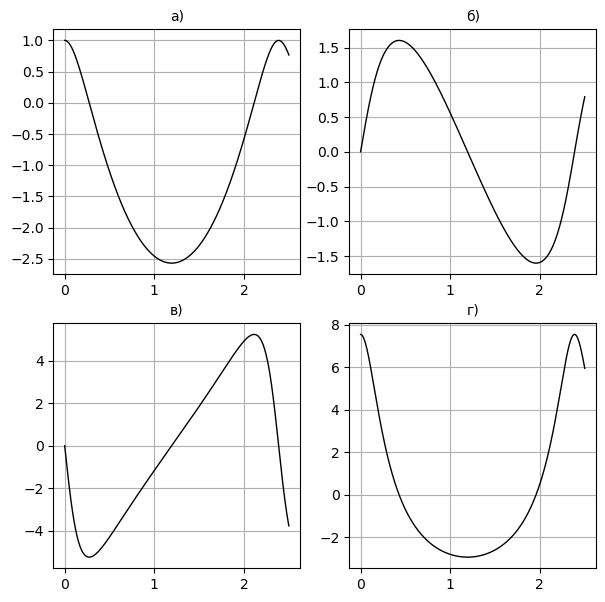

In [4]:
# Ячейка № 4

# визуализация решений
# системы ОДУ (4.36)-(4.39)
fig = plt.figure(figsize=(7, 7))

# визуализация зависимости x=x(t)
ax = plt.subplot(2, 2, 1)
ax.plot(Solv.t[:], Solv.y[0, :], "-k", lw=1)
ax.grid(True)
ax.set_title("а)", fontsize=10)

# визуализация зависимости y=y(t)
ax = plt.subplot(2, 2, 2)
ax.plot(Solv.t[:], Solv.y[2, :], "-k", lw=1)
ax.grid(True)
ax.set_title("б)", fontsize=10)


# визуализация зависимости x'=x'(t)
ax = plt.subplot(2, 2, 3)
ax.plot(Solv.t[:], Solv.y[1, :], "-k", lw=1)
ax.grid(True)
ax.set_title("в)", fontsize=10)

# визуализация зависимости y'=y'(t)
ax = plt.subplot(2, 2, 4)
ax.plot(Solv.t[:], Solv.y[3, :], "-k", lw=1)
ax.grid(True)
ax.set_title("г)", fontsize=10)

plt.show()

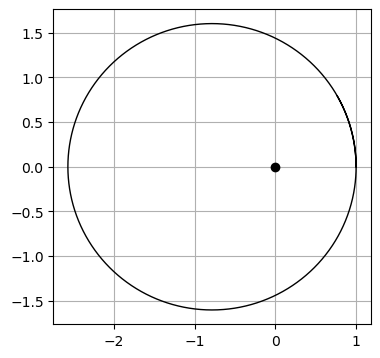

Эксцентриситет орбиты =  0.4400004617665305


In [5]:
# Ячейка № 5

# визуализация траектории
# движения планеты

fig2 = plt.figure(figsize=(9, 9))
ax = plt.subplot(2, 2, 1)
ax.plot(Solv.y[0, :], Solv.y[2, :], "-k", lw=1)
ax.grid(True)
# визуализация положения притягивающего центра
ax.plot(0, 0, "ok")

plt.show()

# вычисление эксцентриситета орбиты
X_max = np.max(Solv.y[0, :])
X_min = np.min(Solv.y[0, :])
Y_min = np.min(Solv.y[2, :])
Y_max = np.max(Solv.y[2, :])

a = (X_max - X_min) / 2
b = (Y_max - Y_min) / 2

if a <= b:
    e = np.sqrt(1 - (a / b) ** 2)
else:
    e = np.sqrt(1 - (b / a) ** 2)
print("Эксцентриситет орбиты = ", e)


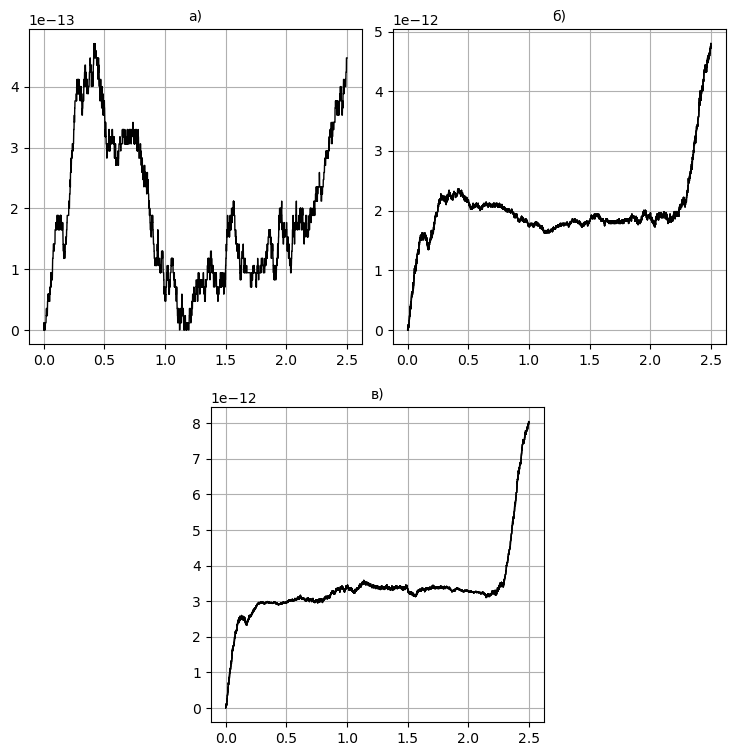

In [6]:
# Ячейка # 6

# инициализация служебного массива
# размерностью 1 х 3
tmp = np.zeros(3)

# определение числа узлов
# временной сетки, в узлах
# которой вычислены
# численные решения
# системы ОДУ (4.36)-(4.39)
N = len(Solv.t)

# вычисление значений
# безразмерного интеграла движения I1
# в соответствие с (4.32)

# инициализация массива I1
# размерностью N x 3,
# используемого для хранения
# значений координат
# безразмерного интеграла движения I1
I1 = np.zeros([N, 3])

# инициализация массива I1_L,
# используемого для хранения модуля
# безразмерного интеграла движения I1
I1_L = np.zeros(N)

# вычисление значений
# безразмерного интеграла движения I1
# в соответствие с (4.32) и его модуля
for i in range(N):
    # размещение в массиве R12
    # значений i-ых координат
    # радиуса-вектора планеты
    R12 = np.array([Solv.y[0, i], Solv.y[2, i], 0])

    # размещение в массиве V12
    # значений i-ых координат
    # скорости планеты
    V12 = np.array([Solv.y[1, i], Solv.y[3, i], 0])

    # вычисление значений
    # безразмерного интеграла движения I1
    # в соответствие с (4.32)
    tmp = np.cross(R12, V12)
    I1[i, 0] = tmp[0]
    I1[i, 1] = tmp[1]
    I1[i, 2] = tmp[2]

    # вычисление значений
    # модуля вектора I1
    I1_L[i] = np.sqrt(np.dot(I1[i], I1[i]))

# инициализация массива I2
# размерностью Nx1,
# используемого для хранения
# значений координат
# безразмерного интеграла движения I2
I2 = np.zeros([N, 3])

# вычисление значений
# безразмерного интеграла движения I2
# в соответствие с (4.33)
for i in range(N):
    I2[i] = 0.5 * (Solv.y[1, i] ** 2 + Solv.y[3, i] ** 2) / (
        4 * np.pi**2
    ) - 1 / np.sqrt(Solv.y[0, i] ** 2 + Solv.y[2, i] ** 2)


# инициализация массива I3
# размерностью N x 3,
# используемого для хранения
# значений координат
# безразмерного интеграла движения I3
I3 = np.zeros([N, 3])

# инициализация массива I3_L
# размерностью N x 3,
# используемого для хранения
# значений координат
# безразмерного интеграла движения I3_L
I3_L = np.zeros([N, 3])

# вычисление значений безразмерного
# интеграла движения I3 соответствие с (4.35)
# его модуля
for i in range(N):
    # размещение в массиве R12
    # значений i-ых координат
    # радиуса-вектора планеты
    R12 = np.array([Solv.y[0, i], Solv.y[2, i], 0])

    # размещение в массиве V12
    # значений i-ых координат
    # скорости планеты
    V12 = np.array([Solv.y[1, i], Solv.y[3, i], 0])

    # вычисление значений
    # безразмерного интеграла движения I3
    # в соответствие с (4.35)
    tmp = (
        np.cross(V12, np.cross(R12, V12)) / (4 * np.pi**2)
        - R12 / np.dot(R12, R12) ** 0.5
    )
    I3[i, 0] = tmp[0]
    I3[i, 1] = tmp[1]
    I3[i, 2] = tmp[2]
    # вычисление значений длины вектора I3
    # в узлах временной сетки
    I3_L[i] = np.dot(I3[i], I3[i]) ** 0.5

# визуализация зависимостей погрешностей
# интегралов движения от времени
fig = plt.figure(figsize=(9, 9))

# визуализация зависимостей
# погрешностей интегралов движения I1, I2, I3
# от времени в едином графическом окне

# задание числа графиков
ax = [None for _ in range(3)]

# задание параметров первого графика
ax[0] = plt.subplot2grid(
    (2, 4),  # задание размера сетки
    # 2 ряда по 4 элемента
    (0, 0),  # задание  положения
    # первого элемента
    colspan=2,
)  # задание числа колонок
# используемых для отображения графика

# аналогично задаем параметры остальных графиков
ax[1] = plt.subplot2grid((2, 4), (0, 2), colspan=2)
ax[2] = plt.subplot2grid((2, 4), (1, 1), colspan=2)

# визуализация зависимостей
# погрешности модуля
# интеграла движения I1
# от времени
ax[0].set_title(r"а)", fontsize=10)
ax[0].plot(Solv.t[:], np.abs(I1_L[:] - I1_L[0]) / np.abs(I1_L[0]) * 100, "-k", lw=1)
ax[0].grid(True)

# визуализация зависимости
# погрешности интеграла движения I2
# от времени
ax[1].set_title(r"б)", fontsize=10)
ax[1].plot(Solv.t[:], np.abs(I2[:] - I2[0]) / np.abs(I2[0]) * 100, "-k", lw=1)
ax[1].grid(True)

# визуализация зависимости
# погрешности модуля
# интеграла движения I3
# от времени
ax[2].set_title(r"в)", fontsize=10)
ax[2].plot(Solv.t[:], np.abs(I3_L[:] - I3_L[0]) / np.abs(I3_L[0]) * 100, "-k", lw=1)
ax[2].grid(True)

plt.show()